# Time to do some analysis based on the forest's predictions...
# This part might need a vhmem node from Sulis

In [1]:
import os
import pickle

import pandas as pd
import numpy as np

from sklearn.model_selection import KFold
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import matthews_corrcoef, roc_auc_score, r2_score, mean_squared_error
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

import matplotlib.pyplot as plt

import seaborn as sns

import plotly.express as px
from plotly import graph_objects as go

import dask
import dask.dataframe as dd
from dask.distributed import Client, LocalCluster

In [2]:
# Note, we could read from the simplified csv, but reading the full thing with dask is actually faster
cluster = LocalCluster(threads_per_worker=1, n_workers=32, memory_limit='64GB')
client = Client(cluster)

pred_df = dd.read_parquet('pred_pubchem.parquet')
print(pred_df.columns)
print(len(pred_df))

simplified_df = pred_df[['idx', 'InChIID', 'InChIKey', 'SMILES', 'MolWt', 'LogP', 'BBB+', 'logBB']]
simplified_df = simplified_df.compute()
print(simplified_df.head())

#if not os.path.exists('pred_pubchem_simplified.csv'):
#    print('Not detecting existing CSV, writing a simplified one to file, this may take a while')
#    simplified_df.to_csv('pred_pubchem_simplified.csv')

2026-07-06 19:04:24,522 - distributed.diskutils - INFO - Found stale lock file and directory '/tmp/dask-worker-space/worker-1mx_y8e6', purging
2026-07-06 19:04:24,522 - distributed.diskutils - INFO - Found stale lock file and directory '/tmp/dask-worker-space/worker-h9eof2v6', purging
2026-07-06 19:04:24,522 - distributed.diskutils - INFO - Found stale lock file and directory '/tmp/dask-worker-space/worker-sb_e2y66', purging
2026-07-06 19:04:24,522 - distributed.diskutils - INFO - Found stale lock file and directory '/tmp/dask-worker-space/worker-yx6zevtz', purging
2026-07-06 19:04:24,522 - distributed.diskutils - INFO - Found stale lock file and directory '/tmp/dask-worker-space/worker-_skyiz4p', purging
2026-07-06 19:04:24,523 - distributed.diskutils - INFO - Found stale lock file and directory '/tmp/dask-worker-space/worker-x683cg2f', purging
2026-07-06 19:04:24,523 - distributed.diskutils - INFO - Found stale lock file and directory '/tmp/dask-worker-space/worker-e0gjzqva', purging

Index(['idx', 'InChIID', 'InChIKey', 'MolWt', 'LogP', 'SMILES', 'C1CCSNC1',
       'C1CNOC1', 'BC', 'C1=CCCN2CCCC(CC1)C2',
       ...
       'C1=COCNC1', 'C1CCNCCCCNCCNCCNCCNCCNCC1', 'BO', 'C1=COCCO1',
       'C1=NCCCC1', 'C1=CCCC=CC=CCC2CCC(CCC=C1)OC2', 'C1COCN1', 'C1CCOC1',
       'BBB+', 'logBB'],
      dtype='object', length=401)
112194965
   idx                                            InChIID  \
0    1  InChI=1S/C9H17NO4/c1-7(11)14-8(5-9(12)13)6-10(...   
1    2  InChI=1S/C9H17NO4/c1-7(11)14-8(5-9(12)13)6-10(...   
2    3  InChI=1S/C7H8O4/c8-5-3-1-2-4(6(5)9)7(10)11/h1-...   
3    4         InChI=1S/C3H9NO/c1-3(5)2-4/h3,5H,2,4H2,1H3   
4    5  InChI=1S/C3H8NO5P/c4-1-3(5)2-9-10(6,7)8/h1-2,4...   

                      InChIKey                            SMILES       MolWt  \
0  RDHQFKQIGNGIED-UHFFFAOYSA-N  CC(=O)OC(CC(=O)[O-])C[N+](C)(C)C  203.238007   
1  RDHQFKQIGNGIED-UHFFFAOYSA-O     CC(=O)OC(CC(=O)O)C[N+](C)(C)C  204.246002   
2  INCSWYKICIYAHB-UHFFFAOYSA-N              O=C

2026-07-06 19:26:10,521 - distributed.scheduler - WARNING - Worker failed to heartbeat within 300 seconds. Closing: <WorkerState 'tcp://127.0.0.1:32913', name: 27, status: running, memory: 0, processing: 0>
2026-07-06 19:26:10,523 - distributed.scheduler - WARNING - Worker failed to heartbeat within 300 seconds. Closing: <WorkerState 'tcp://127.0.0.1:33571', name: 1, status: running, memory: 0, processing: 0>
2026-07-06 19:26:10,523 - distributed.scheduler - WARNING - Worker failed to heartbeat within 300 seconds. Closing: <WorkerState 'tcp://127.0.0.1:34283', name: 7, status: running, memory: 0, processing: 0>
2026-07-06 19:26:10,524 - distributed.scheduler - WARNING - Worker failed to heartbeat within 300 seconds. Closing: <WorkerState 'tcp://127.0.0.1:35745', name: 26, status: running, memory: 0, processing: 0>
2026-07-06 19:26:10,527 - distributed.scheduler - WARNING - Worker failed to heartbeat within 300 seconds. Closing: <WorkerState 'tcp://127.0.0.1:36685', name: 6, status: run

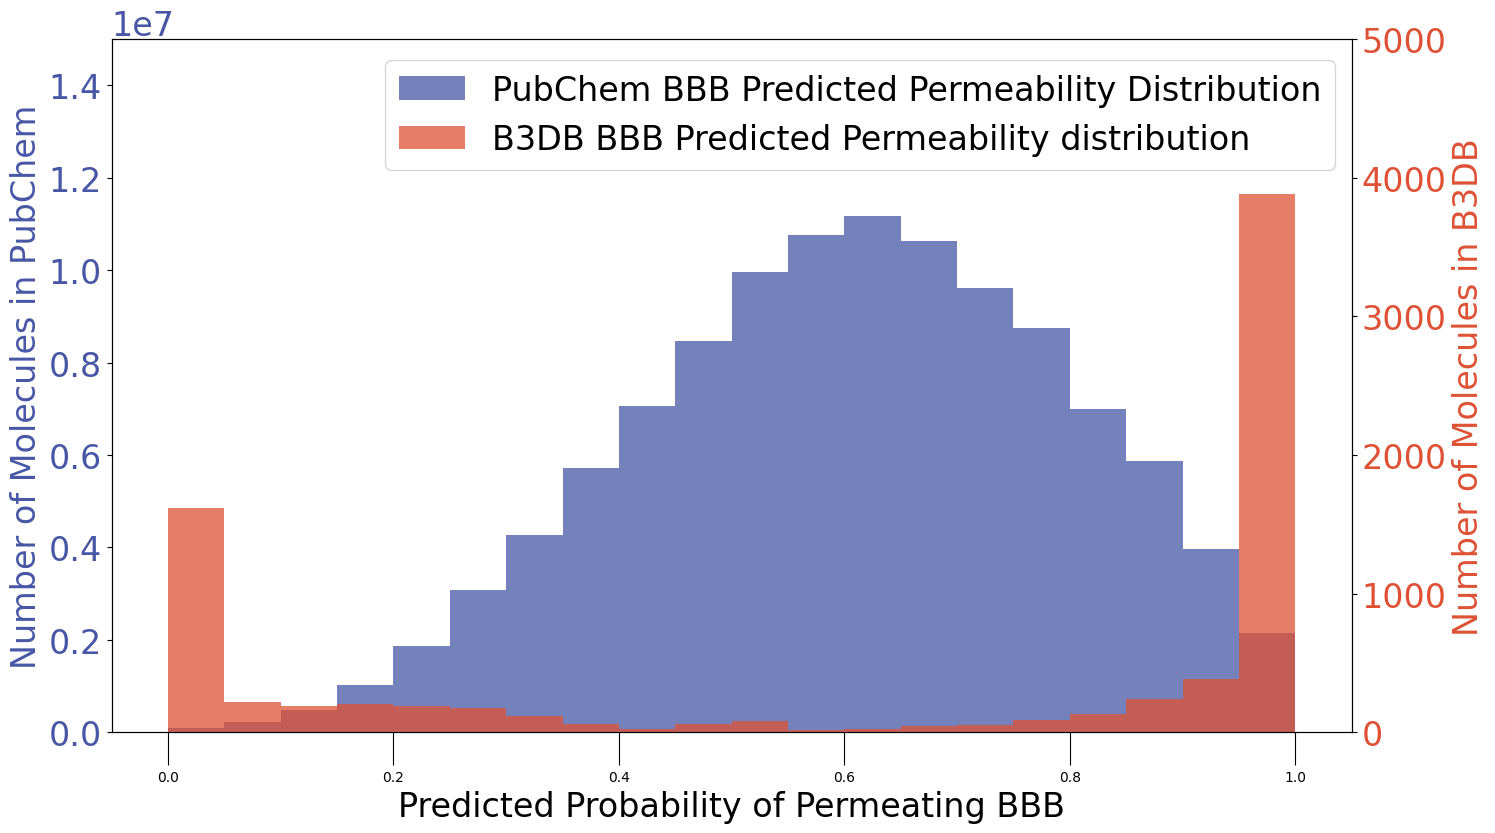

In [3]:
clf = pickle.load(open('forest_clf.pickle', 'rb'))
#rgr = pickle.load(open('forest_rgr.pickle', 'rb'))

vocab_data = dd.read_parquet('./B3DB/B3DB_classification_clean.parquet').compute()
with open('./B3DB/B3DB_classification_clean.parquet.vocab', 'rb') as f:
    vocab, mol_dict = pickle.load(f)

X = vocab_data[vocab]
y = (vocab_data['BBB+/BBB-'] == 'BBB+')
X_logbb = vocab_data.dropna(subset=['logBB'])[vocab]
y_logbb = vocab_data.dropna(subset=['logBB'])['logBB']

p_b3db = clf.predict_proba(X)[:, 1]

fig, ax1 = plt.subplots(figsize=(16, 9))

colour_pubchem = '#4757a5'
ax1.set_xlabel('Predicted Probability of Permeating BBB', fontsize=24)
ax1.set_ylabel('Number of Molecules in PubChem', color=colour_pubchem, fontsize=24)
ax1.tick_params(axis='y', labelcolor=colour_pubchem, labelsize=24)
ax1.tick_params(axis='x', size=24)
ax1.yaxis.get_offset_text().set_size(24)

h1 = ax1.hist(simplified_df['BBB+'], bins=20, alpha=0.75, color=colour_pubchem, label='PubChem BBB Predicted Permeability Distribution')
np.savetxt("hist_pubchem.csv", h1[0])
np.savetxt("histbins_pubchem.csv", h1[1])

colour_b3db = '#de5134'
ax2 = ax1.twinx()
ax2.set_ylabel('Number of Molecules in B3DB', color=colour_b3db, fontsize=24)
ax2.tick_params(axis='y', labelcolor=colour_b3db, labelsize=24)

h2 = ax2.hist(p_b3db, bins=20, alpha=0.75, color=colour_b3db, label='B3DB BBB Predicted Permeability distribution')
np.savetxt("hist_b3db.csv", h2[0])
np.savetxt("histbins_b3db.csv", h2[1])

ax1.set_ylim(0, 1.5e7)
ax2.set_ylim(0, 5000)
fig.legend(fontsize=24, loc='upper right', bbox_to_anchor=(0.9, 0.875))
fig.savefig('histogram_bbbp.png')

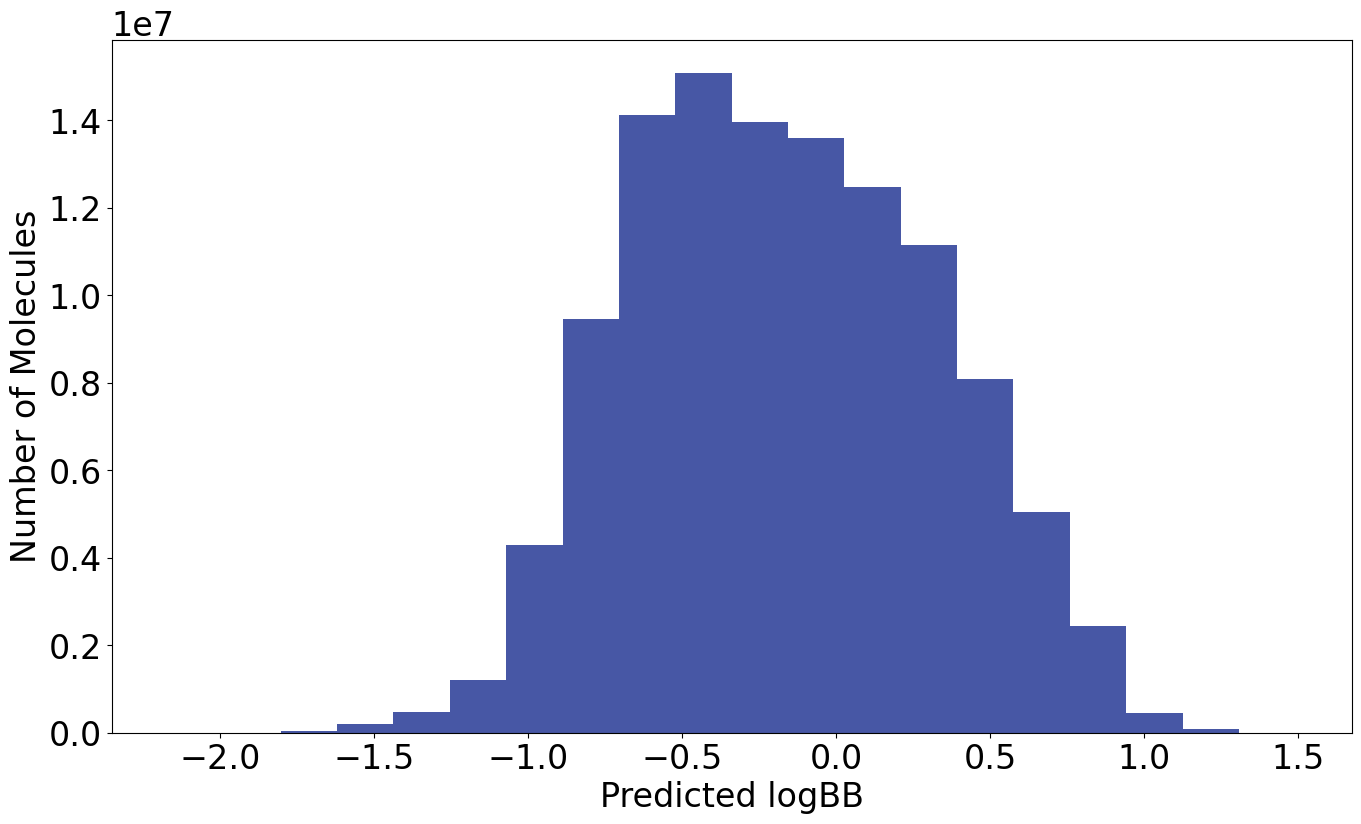

In [4]:
plt.figure(figsize=(16, 9))
plt.hist(simplified_df['logBB'], bins=20, color=colour_pubchem)
plt.xlabel('Predicted logBB', fontsize=24)
plt.ylabel('Number of Molecules', fontsize=24)
plt.xticks(fontsize=24)
plt.yticks(fontsize=24)
plt.gca().yaxis.get_offset_text().set_size(24)
plt.savefig('histogram logbb.png')

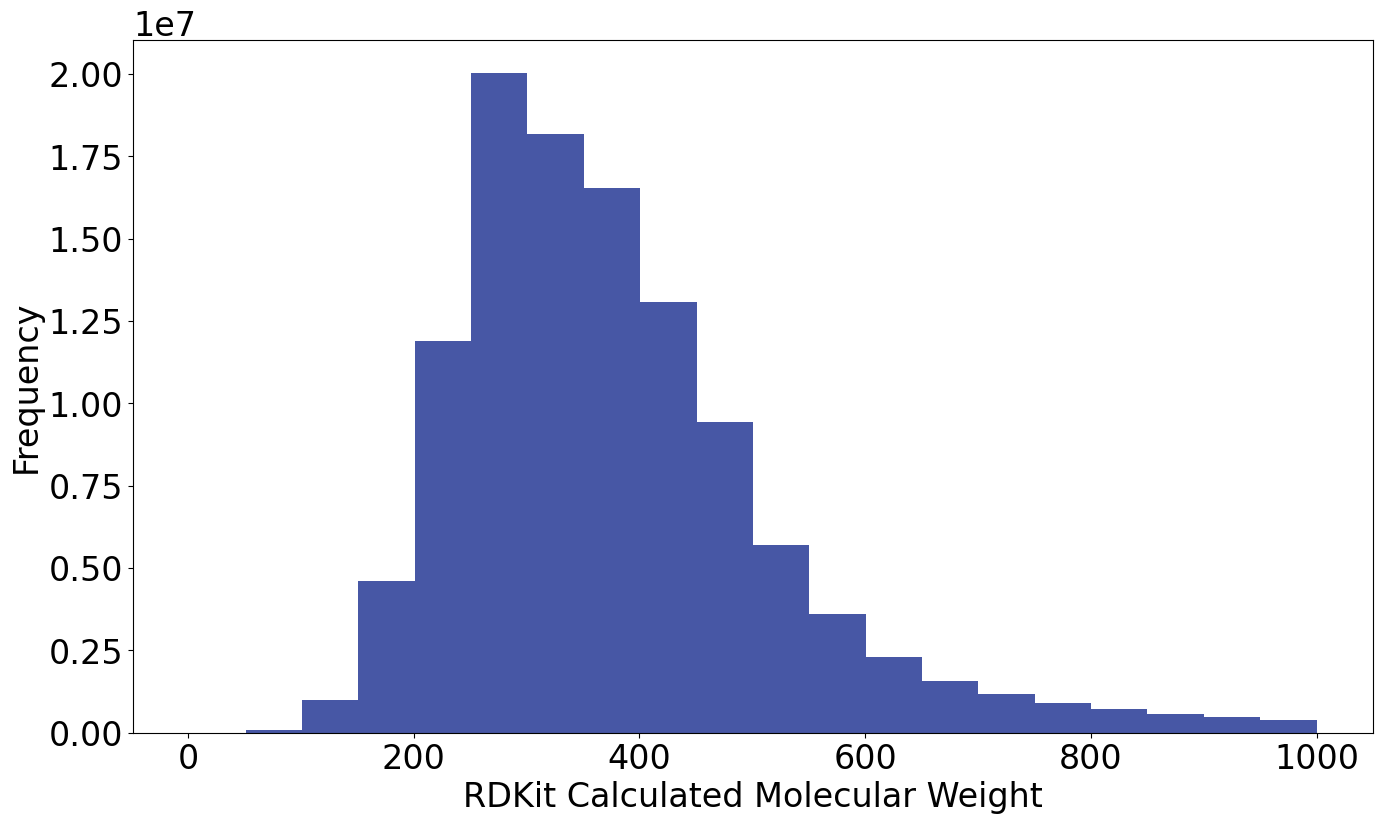

In [5]:
plt.figure(figsize=(16, 9))
plt.hist(simplified_df['MolWt'], bins=20, color=colour_pubchem)
plt.xlabel('RDKit Calculated Molecular Weight', fontsize=24)
plt.ylabel('Frequency', fontsize=24)
plt.xticks(fontsize=24)
plt.yticks(fontsize=24)
plt.gca().yaxis.get_offset_text().set_size(24)

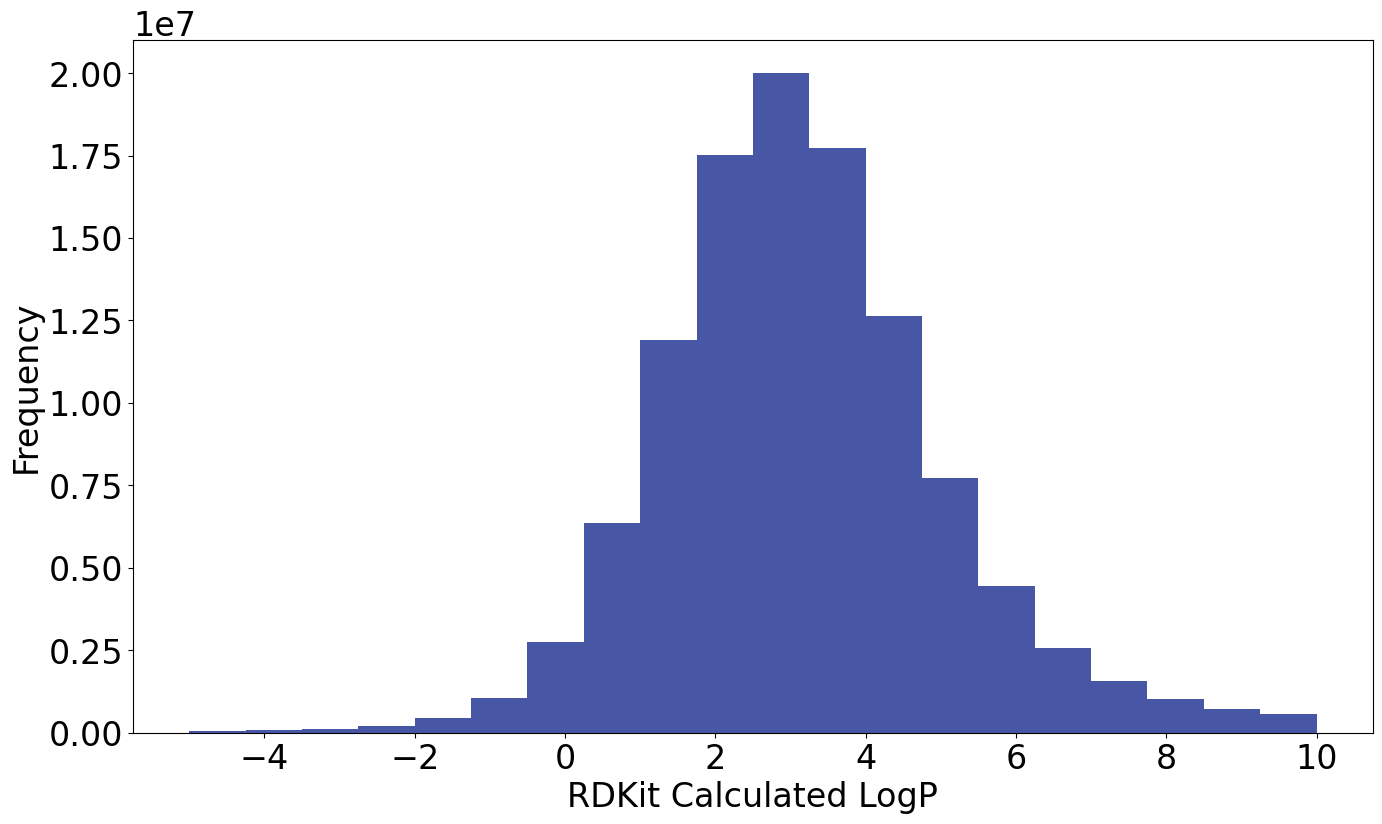

In [6]:
plt.figure(figsize=(16, 9))
plt.hist(simplified_df['LogP'], bins=20, range=(-5,10), color=colour_pubchem)
plt.xlabel('RDKit Calculated LogP', fontsize=24)
plt.ylabel('Frequency', fontsize=24)
plt.xticks(fontsize=24)
plt.yticks(fontsize=24)
plt.gca().yaxis.get_offset_text().set_size(24)

# So, reviewers have asked us for a few things
## The first of these is to look at the actual similarity between PubChem, B3DB and our candidates
## We could do this with MCES like this paper https://www.biorxiv.org/content/10.1101/2023.03.27.534311v1
## But, that's slow and complicated. Let's go with Morgan Fingerprints with Tanimoto/Jaccard distance

In [7]:
from rdkit import Chem
from rdkit.Chem import AllChem
from rdkit.Chem import MACCSkeys
from rdkit import DataStructs
import umap

def compute_morgan(inchi):
    morgan_vector = np.zeros((2048,), dtype=np.int8)
    try:
        mol = Chem.MolFromInchi(inchi)
        morgan_fp = AllChem.GetMorganFingerprintAsBitVect(mol, radius=3, nBits=2048)

        DataStructs.ConvertToNumpyArray(morgan_fp, morgan_vector)
    except:
        pass

    return morgan_vector

def compute_maccs(inchi):
    maccs_vector = np.zeros((167,), dtype=np.int8)

    try:
        mol = Chem.MolFromInchi(inchi)
        maccs_fp = MACCSkeys.GenMACCSKeys(mol)

        DataStructs.ConvertToNumpyArray(maccs_fp, maccs_vector)
    except:
        pass

    return maccs_vector

In [8]:
vocab_data['Morgan'] = vocab_data['Inchi'].map(compute_morgan)
vocab_data['MACCS'] = vocab_data['Inchi'].map(compute_maccs)

RDKit WARNING: [19:06:22] WARNING: not removing hydrogen atom without neighbors
[19:06:22] WARNING: not removing hydrogen atom without neighbors
RDKit ERROR: [19:06:25] Explicit valence for atom # 10 N, 4, is greater than permitted
[19:06:25] Explicit valence for atom # 10 N, 4, is greater than permitted
RDKit WARNING: [19:06:22] WARNING:  Problems/mismatches: Mobile-H( Mobile-H groups: Attachment points, Number)
[19:06:22] WARNING:  Problems/mismatches: Mobile-H( Mobile-H groups: Attachment points, Number)
[19:06:28] WARNING: not removing hydrogen atom without neighbors
RDKit WARNING: [19:06:28] WARNING: not removing hydrogen atom without neighbors
RDKit ERROR: [19:06:25] ERROR: Explicit valence for atom # 10 N, 4, is greater than permitted
[19:06:25] ERROR: Explicit valence for atom # 10 N, 4, is greater than permitted
[19:06:37] Explicit valence for atom # 10 N, 4, is greater than permitted
RDKit ERROR: [19:06:37] Explicit valence for atom # 10 N, 4, is greater than permitted


In [9]:
pos_cand = pd.read_csv('../common/candidates/bbbp_positive_pubchem.csv', comment=';') 
neg_cand = pd.read_csv('../common/candidates/bbbp_negative_pubchem.csv', comment=';')

pos_cand['Morgan'] = pos_cand['InChIID'].map(compute_morgan)
pos_cand['MACCS'] = pos_cand['InChIID'].map(compute_maccs)
neg_cand['Morgan'] = neg_cand['InChIID'].map(compute_morgan)
neg_cand['MACCS'] = neg_cand['InChIID'].map(compute_maccs)

In [10]:
# Take a 100k subset from our full PubChem dataset
pred_df = pred_df.set_index('idx')
idx = np.random.choice(pred_df.index.compute(), size=100000, replace=False)
pubchem_umap = np.stack(pred_df['InChIID'][idx].map(compute_morgan, meta=pd.Series(dtype=np.uint8, name='Morgan')).compute(), axis=0)

b3db_umap = np.stack(vocab_data['Morgan'], axis=0)
pos_umap = np.stack(pos_cand['Morgan'], axis=0)
neg_umap = np.stack(neg_cand['Morgan'], axis=0)

reducer = umap.UMAP(metric='jaccard', n_neighbors=100, min_dist=0.1, n_components=2, random_state=1209)

pubchem_umap = reducer.fit_transform(pubchem_umap)

b3db_umap = reducer.transform(b3db_umap)
pos_umap = reducer.transform(pos_umap)
neg_umap = reducer.transform(neg_umap)

[19:07:32] WARNING: not removing hydrogen atom without neighbors
[19:07:33] WARNING:  Problems/mismatches: Mobile-H( Hydrogens: Locations or number; Mobile-H groups: Missing, Attachment points)
[19:07:33] WARNING:  Problems/mismatches: Mobile-H( Hydrogens: Number; Mobile-H groups: Missing, Attachment points; Charge(s): Do not match)
[19:07:33] WARNING:  Problems/mismatches: Mobile-H( Charge(s): Do not match)
[19:07:33] expect radical to be either 2 or 3 while getting . Ignore radical.
[19:07:33] expect radical to be either 2 or 3 while getting . Ignore radical.
[19:07:33] expect radical to be either 2 or 3 while getting . Ignore radical.
[19:07:33] WARNING:  Problems/mismatches: Mobile-H( Mobile-H groups: Attachment points, Number)
[19:07:33] WARNING: not removing hydrogen atom without neighbors
[19:07:33] WARNING:  Problems/mismatches: Mobile-H( Hydrogens: Locations or number, Number; Charge(s): Do not match)
[19:07:37] WARNING:  Problems/mismatches: Mobile-H( Hydrogens: Number; Mo

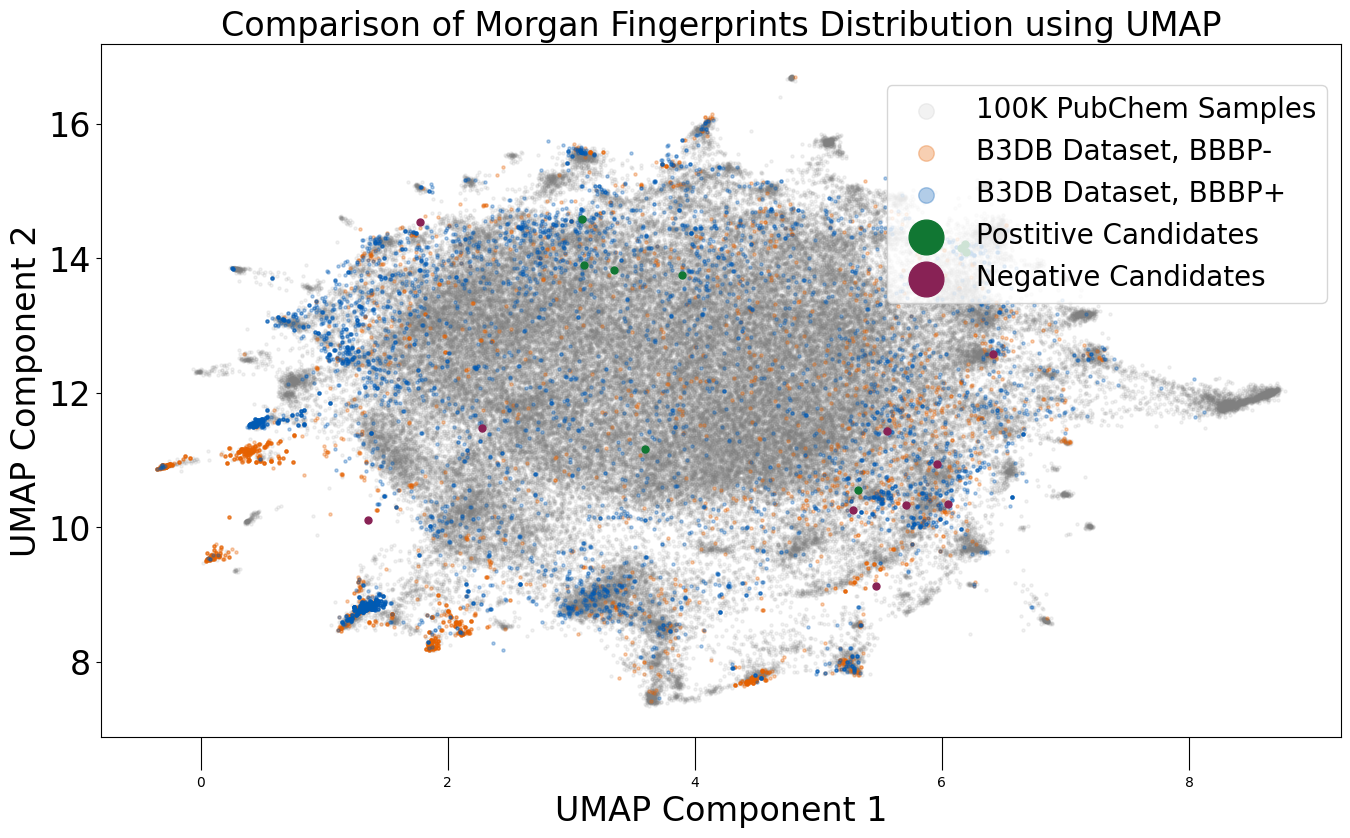

In [11]:
fig, ax = plt.subplots(figsize=(16, 9))

ax.scatter(pubchem_umap[:, 0], pubchem_umap[:, 1], s=5, color='gray', label='100K PubChem Samples', alpha=0.1)

ax.scatter(
    b3db_umap[vocab_data['BBB+/BBB-']=='BBB-', 0,], b3db_umap[vocab_data['BBB+/BBB-']=='BBB-', 1],
    s=5, color='#E66100', label='B3DB Dataset, BBBP-', alpha=0.3)
ax.scatter(
    b3db_umap[vocab_data['BBB+/BBB-']=='BBB+', 0,], b3db_umap[vocab_data['BBB+/BBB-']=='BBB+', 1],
    s=5, color='#005AB5', label='B3DB Dataset, BBBP+', alpha=0.3)

ax.scatter(pos_umap[:, 0], pos_umap[:, 1], s=25, color='#117733', label='Postitive Candidates')
ax.scatter(neg_umap[:, 0], neg_umap[:, 1], s=25, color='#882255', label='Negative Candidates')

ax.set_title('Comparison of Morgan Fingerprints Distribution using UMAP', fontsize=24)
ax.set_xlabel('UMAP Component 1', fontsize=24)
ax.set_ylabel('UMAP Component 2', fontsize=24)
ax.tick_params(axis='y', labelsize=24)
ax.tick_params(axis='x', size=24)

fig.legend(fontsize=20, markerscale=5, loc='upper right', bbox_to_anchor=(0.9, 0.85))
fig.savefig('umap_morgan.png')

In [12]:
# Take a 100k subset from our full PubChem dataset
pred_df = pred_df.set_index('idx')
idx = np.random.choice(pred_df.index.compute(), size=100000, replace=False)
pubchem_umap = np.stack(pred_df['InChIID'][idx].map(compute_maccs, meta=pd.Series(dtype=np.uint8, name='MACCS')).compute(), axis=0)

b3db_umap = np.stack(vocab_data['MACCS'], axis=0)
pos_umap = np.stack(pos_cand['MACCS'], axis=0)
neg_umap = np.stack(neg_cand['MACCS'], axis=0)

reducer = umap.UMAP(metric='jaccard', n_neighbors=100, min_dist=0.1, n_components=2, random_state=1209)

pubchem_umap = reducer.fit_transform(pubchem_umap)

b3db_umap = reducer.transform(b3db_umap)
pos_umap = reducer.transform(pos_umap)
neg_umap = reducer.transform(neg_umap)

/home/m/matgms/.local/share/virtualenvs/ipynb-CmZVQ3Eh/lib/python3.9/site-packages/dask/dataframe/core.py:5070: UserWarning: New index has same name as existing, this is a no-op.
  warnings.warn(
[19:27:05] WARNING:  Problems/mismatches: Mobile-H( Mobile-H groups: Number)
[19:27:05] WARNING:  Problems/mismatches: Mobile-H( Hydrogens: Number; Mobile-H groups: Falsely present, Attachment points; Charge(s): Do not match)
[19:27:06] WARNING:  Problems/mismatches: Mobile-H( Hydrogens: Number; Mobile-H groups: Missing, Attachment points; Charge(s): Do not match)
[19:27:06] WARNING:  Problems/mismatches: Mobile-H( Hydrogens: Locations or number, Number; Mobile-H groups: One instead of multiple, Attachment points, Number; Charge(s): Do not match; Proton balance: Does not match)
[19:27:06] WARNING:  Problems/mismatches: Mobile-H( Mobile-H groups: Attachment points, Number)
[19:27:06] WARNING:  Problems/mismatches: Mobile-H( Hydrogens: Locations or number; Mobile-H groups: Attachment points, Num

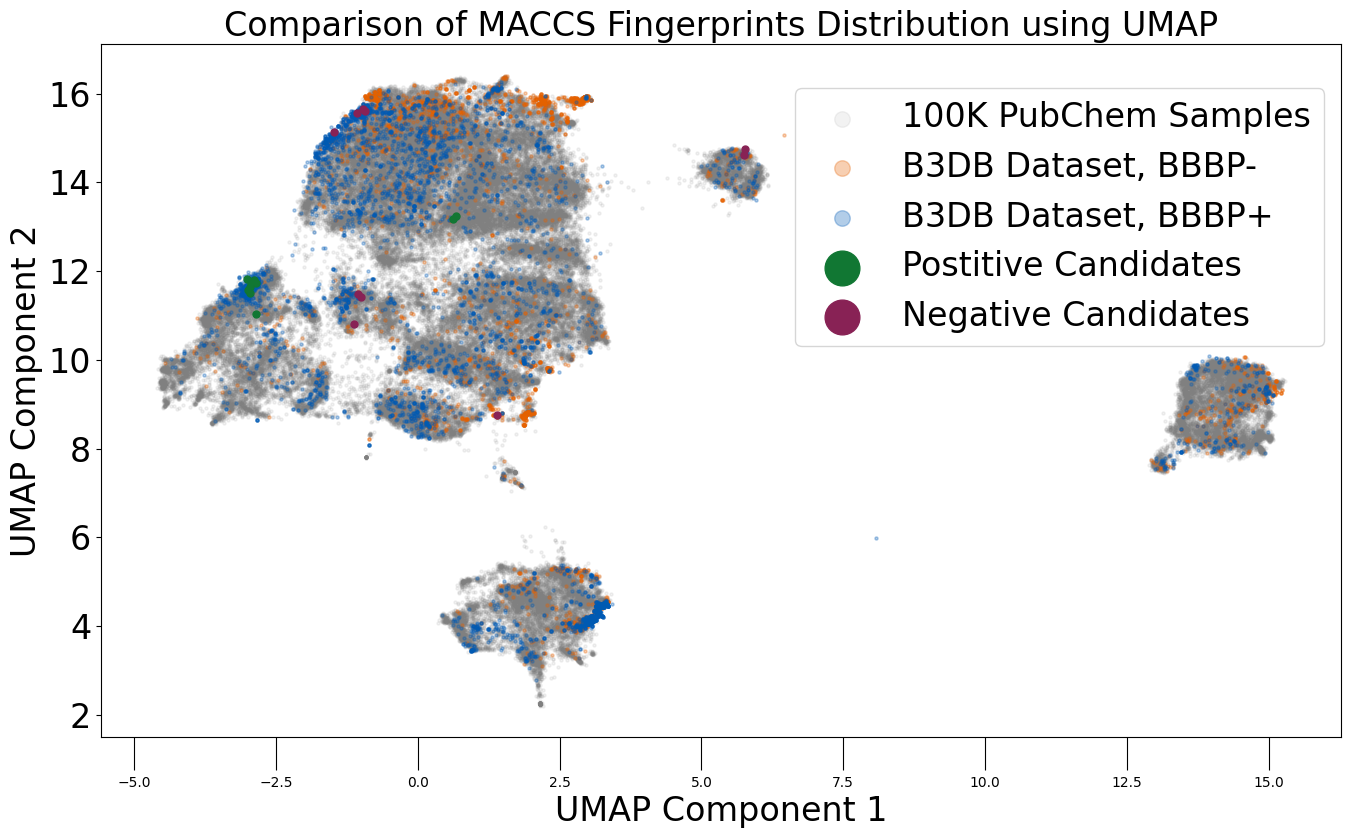

In [13]:
fig, ax = plt.subplots(figsize=(16, 9))

ax.scatter(pubchem_umap[:, 0], pubchem_umap[:, 1], s=5, color='gray', label='100K PubChem Samples', alpha=0.1)

ax.scatter(
    b3db_umap[vocab_data['BBB+/BBB-']=='BBB-', 0,], b3db_umap[vocab_data['BBB+/BBB-']=='BBB-', 1],
    s=5, color='#E66100', label='B3DB Dataset, BBBP-', alpha=0.3)
ax.scatter(
    b3db_umap[vocab_data['BBB+/BBB-']=='BBB+', 0,], b3db_umap[vocab_data['BBB+/BBB-']=='BBB+', 1],
    s=5, color='#005AB5', label='B3DB Dataset, BBBP+', alpha=0.3)

ax.scatter(pos_umap[:, 0], pos_umap[:, 1], s=25, color='#117733', label='Postitive Candidates')
ax.scatter(neg_umap[:, 0], neg_umap[:, 1], s=25, color='#882255', label='Negative Candidates')

ax.set_title('Comparison of MACCS Fingerprints Distribution using UMAP', fontsize=24)
ax.set_xlabel('UMAP Component 1', fontsize=24)
ax.set_ylabel('UMAP Component 2', fontsize=24)
ax.tick_params(axis='y', labelsize=24)
ax.tick_params(axis='x', size=24)

fig.legend(fontsize=24, markerscale=5, loc='upper right', bbox_to_anchor=(0.9, 0.85))
fig.savefig('umap_maccs.png')